# Investigate the MAE distribution of sampled configurations of molecules

In [31]:
import importlib
import os
import sys
import statistics

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch

import helper
from modelforge.dataset.dataset import initialize_datamodule
from modelforge.dataset.utils import RandomRecordSplittingStrategy, SplittingStrategy

sns.set_theme()
sns.set_context("notebook")
%matplotlib inline

## Load an AIMNet2 model checkpoint

In [3]:
from modelforge.potential.potential import load_inference_model_from_checkpoint

# Helper utilities to load the example model checkpoint bundled with modelforge.
from modelforge.utils.io import get_path_string
# from modelforge.ase.tests import data

checkpoint_file_path = f"trained_potentials/AIMNet2_tmQMOpenFF_full.ckpt" # This is an example model used in testing 
potential = load_inference_model_from_checkpoint(checkpoint_file_path, jit=False)
print(f"Loaded checkpoint: {checkpoint_file_path}")

2026-07-01 15:49:50.065 | DEBUG    | modelforge.potential.potential:generate_potential:889 - training_parameter=None
2026-07-01 15:49:50.066 | DEBUG    | modelforge.potential.potential:generate_potential:890 - potential_parameter=AimNet2Parameters(potential_name='AimNet2', only_unique_pairs=False, core_parameter=CoreParameter(number_of_radial_basis_functions=64, maximum_interaction_radius=0.49999999999999994, number_of_interaction_modules=3, interaction_module_hidden_layers=[[512, 256], [512, 256], [512, 256, 256]], output_module_hidden_layers=[128, 128], activation_function_parameter=ActivationFunctionConfig(activation_function_name='GeLU', activation_function_arguments=None, activation_function=GELU(approximate='none')), featurization=Featurization(properties_to_featurize=['atomic_number', 'per_system_total_charge', 'per_system_spin_state'], atomic_number=AtomicNumber(maximum_atomic_number=101, number_of_per_atom_features=512), atomic_period=AtomicPeriod(maximum_period=8, number_of_p

Loaded checkpoint: trained_potentials/AIMNet2_tmQMOpenFF_full.ckpt


## Load the tmQM-OpenFF dataset

In [3]:
# initialize datasets as in training
dm = initialize_datamodule(
    dataset_name="tmqm_openff_local",
    version_select="full_dataset_v1.4c",
    splitting_strategy=RandomRecordSplittingStrategy(
            seed=42,
            split=[0.8, 0.1, 0.1],
        ),
    local_cache_dir="../cache",
    batch_size=1,
    dataset_cache_dir="./dataset_cache",
    local_yaml_file = "/Users/syan/workdir/modelforge-experiments/experiments/exp12/cache/tmqm-openff_ext/tmqm_openff_local.yaml", #note, this should in general be the full path to the yaml file,
                                                        #but for testing purposes on CI, we need to use a placeholder
                                                        #i.e., path_to_file, which the test will replace.
    properties_of_interest= ["atomic_numbers", "positions", "dft_total_energy", "scf_dipole", "total_charge", "lowdin_partial_charges", "per_system_spin_multiplicity", "dft_total_force"],
    properties_assignment={
        "atomic_numbers": "atomic_numbers",
        "positions": "positions",
        "E": "dft_total_energy",
        "F": "dft_total_force",
        "total_charge": "total_charge",
        "dipole_moment": "scf_dipole",
        "partial_charges": "lowdin_partial_charges",
        "spin_multiplicity": "per_system_spin_multiplicity",
    }
)

2026-07-05 14:41:24.300 | DEBUG    | modelforge.dataset.dataset:__init__:352 - Loading config data from user specified file: /Users/syan/workdir/modelforge-experiments/experiments/exp12/cache/tmqm-openff_ext/tmqm_openff_local.yaml
2026-07-05 14:41:24.305 | INFO     | modelforge.dataset.dataset:__init__:381 - Using dataset version full_dataset_v1.4c
2026-07-05 14:41:24.307 | DEBUG    | modelforge.dataset.dataset:_acquire_dataset:439 - Unzipped npz file tmqm_openff_local.npz already exists in ../cache
2026-07-05 14:41:24.307 | DEBUG    | modelforge.dataset.dataset:_from_file_cache:1108 - Loading processed data from ../cache/tmqm_openff_local.npz generated on 2026-06-25 11:31:29.092739
2026-07-05 14:41:24.307 | DEBUG    | modelforge.dataset.dataset:_from_file_cache:1111 - Properties of Interest in .npz file: ['atomic_numbers', 'dft_total_energy', 'scf_dipole', 'total_charge', 'per_system_spin_multiplicity', 'positions', 'lowdin_partial_charges', 'dft_total_force']
2026-07-05 14:41:24.309 

Validating file ../cache/tmqm_openff_local.npz


2026-07-05 14:41:24.801 | INFO     | modelforge.dataset.dataset:_calculate_atomic_self_energies:1473 - Using atomic self energies provided by the dataset.
2026-07-05 14:41:24.801 | DEBUG    | modelforge.dataset.dataset:prepare_data:1370 - Process dataset ...
2026-07-05 14:41:24.801 | INFO     | modelforge.dataset.dataset:_per_datapoint_operations:1568 - Performing per datapoint operations in the dataset
2026-07-05 14:41:24.801 | INFO     | modelforge.dataset.dataset:_per_datapoint_operations:1570 - Removing self energies from the dataset
Calculating pairlist for dataset: 100%|██████████| 4076/4076 [00:30<00:00, 134.17it/s]
2026-07-05 14:42:08.674 | INFO     | modelforge.dataset.utils:calculate_mean_and_variance:167 - Calculating mean and variance of atomic energies
100%|██████████| 1592/1592 [00:11<00:00, 138.48it/s]
2026-07-05 14:42:20.177 | INFO     | modelforge.dataset.utils:calculate_mean_and_variance:179 - Mean and standard deviation of the dataset:{'per_atom_energy_mean': tensor(

### Use data module

In [9]:
test_dataloader = dm.test_dataloader()

In [6]:
predictions = []
with torch.no_grad():  # Disable gradient tracking to save memory
    for batch in test_dataloader:
        nnp_output = potential(batch.nnp_input)
        predictions.append(nnp_output)

/Users/syan/workdir/modelforge/modelforge/potential/processing.py:1112: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /Users/runner/miniforge3/conda-bld/libtorch_1741562946353/work/aten/src/ATen/SparseCsrTensorImpl.cpp:55.)
  neighbor_matrix_csr = neighbor_matrix_coo.to_sparse_csr()


In [9]:
torch.save(predictions, "predictions.pt")

Task was destroyed but it is pending!
task: <Task pending name='Task-116' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/syan/miniforge3/envs/modelforge/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-117' coro=<Kernel.shell_main() running at /Users/syan/miniforge3/envs/modelforge/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/syan/miniforge3/envs/modelforge/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:563]>
/Users/syan/miniforge3/envs/modelforge/lib/python3.12/copyreg.py:107: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def _slotnames(cls):
Task was destroyed but it is pending!
task: <Task pending name='Task-117' coro=<Kernel.shell_main() running at /Users/syan/miniforge3/envs/modelforge/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]>


In [5]:
predictions = torch.load("predictions.pt")
len(predictions)

79806

In [44]:
predictions[0]["per_system_energy"]

tensor([[-213.5530]])

In [24]:
predictions[0]["atomic_numbers"]

tensor([26, 15,  6,  8,  6,  8,  6,  8,  6,  8,  6,  1,  1,  1,  6,  1,  1,  1,
         6,  6,  1,  6,  1,  6,  1,  6,  1,  6,  1], dtype=torch.int32)

In [102]:
atomic_numbers = []
true_per_system_energy = []
per_system_total_charge = []
per_system_spin_state = []
predicted_energy = []
with torch.no_grad():  # Disable gradient tracking to save memory
    for i, batch in enumerate(test_dataloader):
        atomic_numbers.append(
            str(predictions[i]["atomic_numbers"].tolist())
        )
        true_per_system_energy.append(batch.metadata.per_system_energy.item())
        per_system_total_charge.append(batch.nnp_input.per_system_total_charge.item())
        per_system_spin_state.append(batch.nnp_input.per_system_spin_state.item())
        predicted_energy.append(predictions[i]["per_system_energy"].item())

In [100]:
batch.nnp_input.per_system_total_charge

tensor([[0.]])

In [104]:
def group_record_indices(predictions):
    record_index_collections = []
    j = 0
    for i, configuration in enumerate(predictions):
        if i == 0:
            record_index_collections.append(
                {
                    "index": [0],
                    # "predictions": [predictions[0]],
                    # "true_per_system_energy": [true_per_system_energy[0]],
                    # "per_system_spin_state": [per_system_spin_state[0]],
                }
            )
        else:
            if predictions[i]["atomic_numbers"].shape[0] == predictions[i - 1]["atomic_numbers"].shape[0]:
                if torch.all(torch.eq(predictions[i]["atomic_numbers"], predictions[i - 1]["atomic_numbers"])):
                    record_index_collections[j]["index"].append(i)
                    # record_collections[j]["predictions"].append(predictions[i])
                    # record_collections[j]["true_per_system_energy"].append(true_per_system_energy[i])
                    # record_collections[j]["per_system_spin_state"].append(per_system_spin_state[i])
            else:
                j += 1  # create next record
                record_index_collections.append(
                    {
                        "index": [i],
                        # "predictions": [predictions[i]],
                        # "true_per_system_energy": [true_per_system_energy[i]],
                        # "per_system_spin_state": [per_system_spin_state[i]],
                    }
                )

    return record_index_collections

In [105]:
record_index_collections = group_record_indices(predictions)

In [107]:
len(record_index_collections)

1866

In [109]:
df = pd.DataFrame(
    {
        "atomic_numbers": atomic_numbers,
        "per_system_total_charge": per_system_total_charge,
        "per_system_spin_state": per_system_spin_state,
        "predicted_energy": predicted_energy,
        "true_per_system_energy": true_per_system_energy,
        "errors": np.array(predicted_energy) - np.array(true_per_system_energy),
    }
)

In [123]:
df[:10]

,atomic_numbers,per_system_total_charge,per_system_spin_state,predicted_energy,true_per_system_energy,errors
0,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,1.0,-213.552979,-478.663016,265.110038
1,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,3.0,-41.719406,-151.343364,109.623958
2,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,5.0,151.275696,203.480220,-52.204524
3,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,1.0,-200.953278,-460.845454,259.892176
4,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,3.0,-47.498245,-154.530202,107.031957
5,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,5.0,135.804382,187.045205,-51.240823
6,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,1.0,-174.033997,-441.079343,267.045347
7,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,3.0,-8.533859,-130.452969,121.919109
8,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,5.0,173.724426,222.600021,-48.875594
9,"[26, 15, 6, 8, 6, 8, 6, 8, 6, 8, 6, 1, 1, 1, 6...",0.0,1.0,-184.587860,-449.081093,264.493233


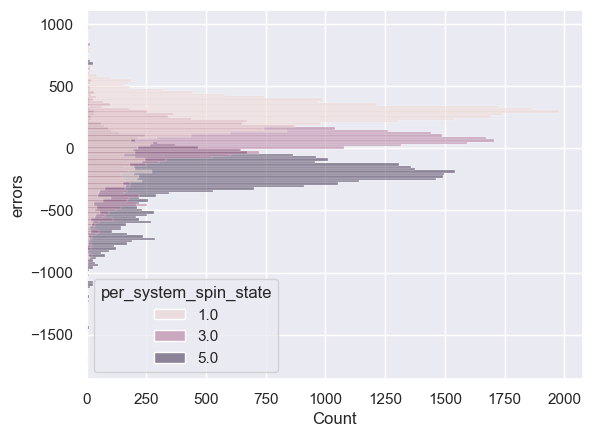

In [92]:
sns.histplot(df, y="errors", hue="per_system_spin_state")
plt.show()

In [108]:
n_records = 15
n_rows = record_index_collections[n_records - 1]["index"][-1]

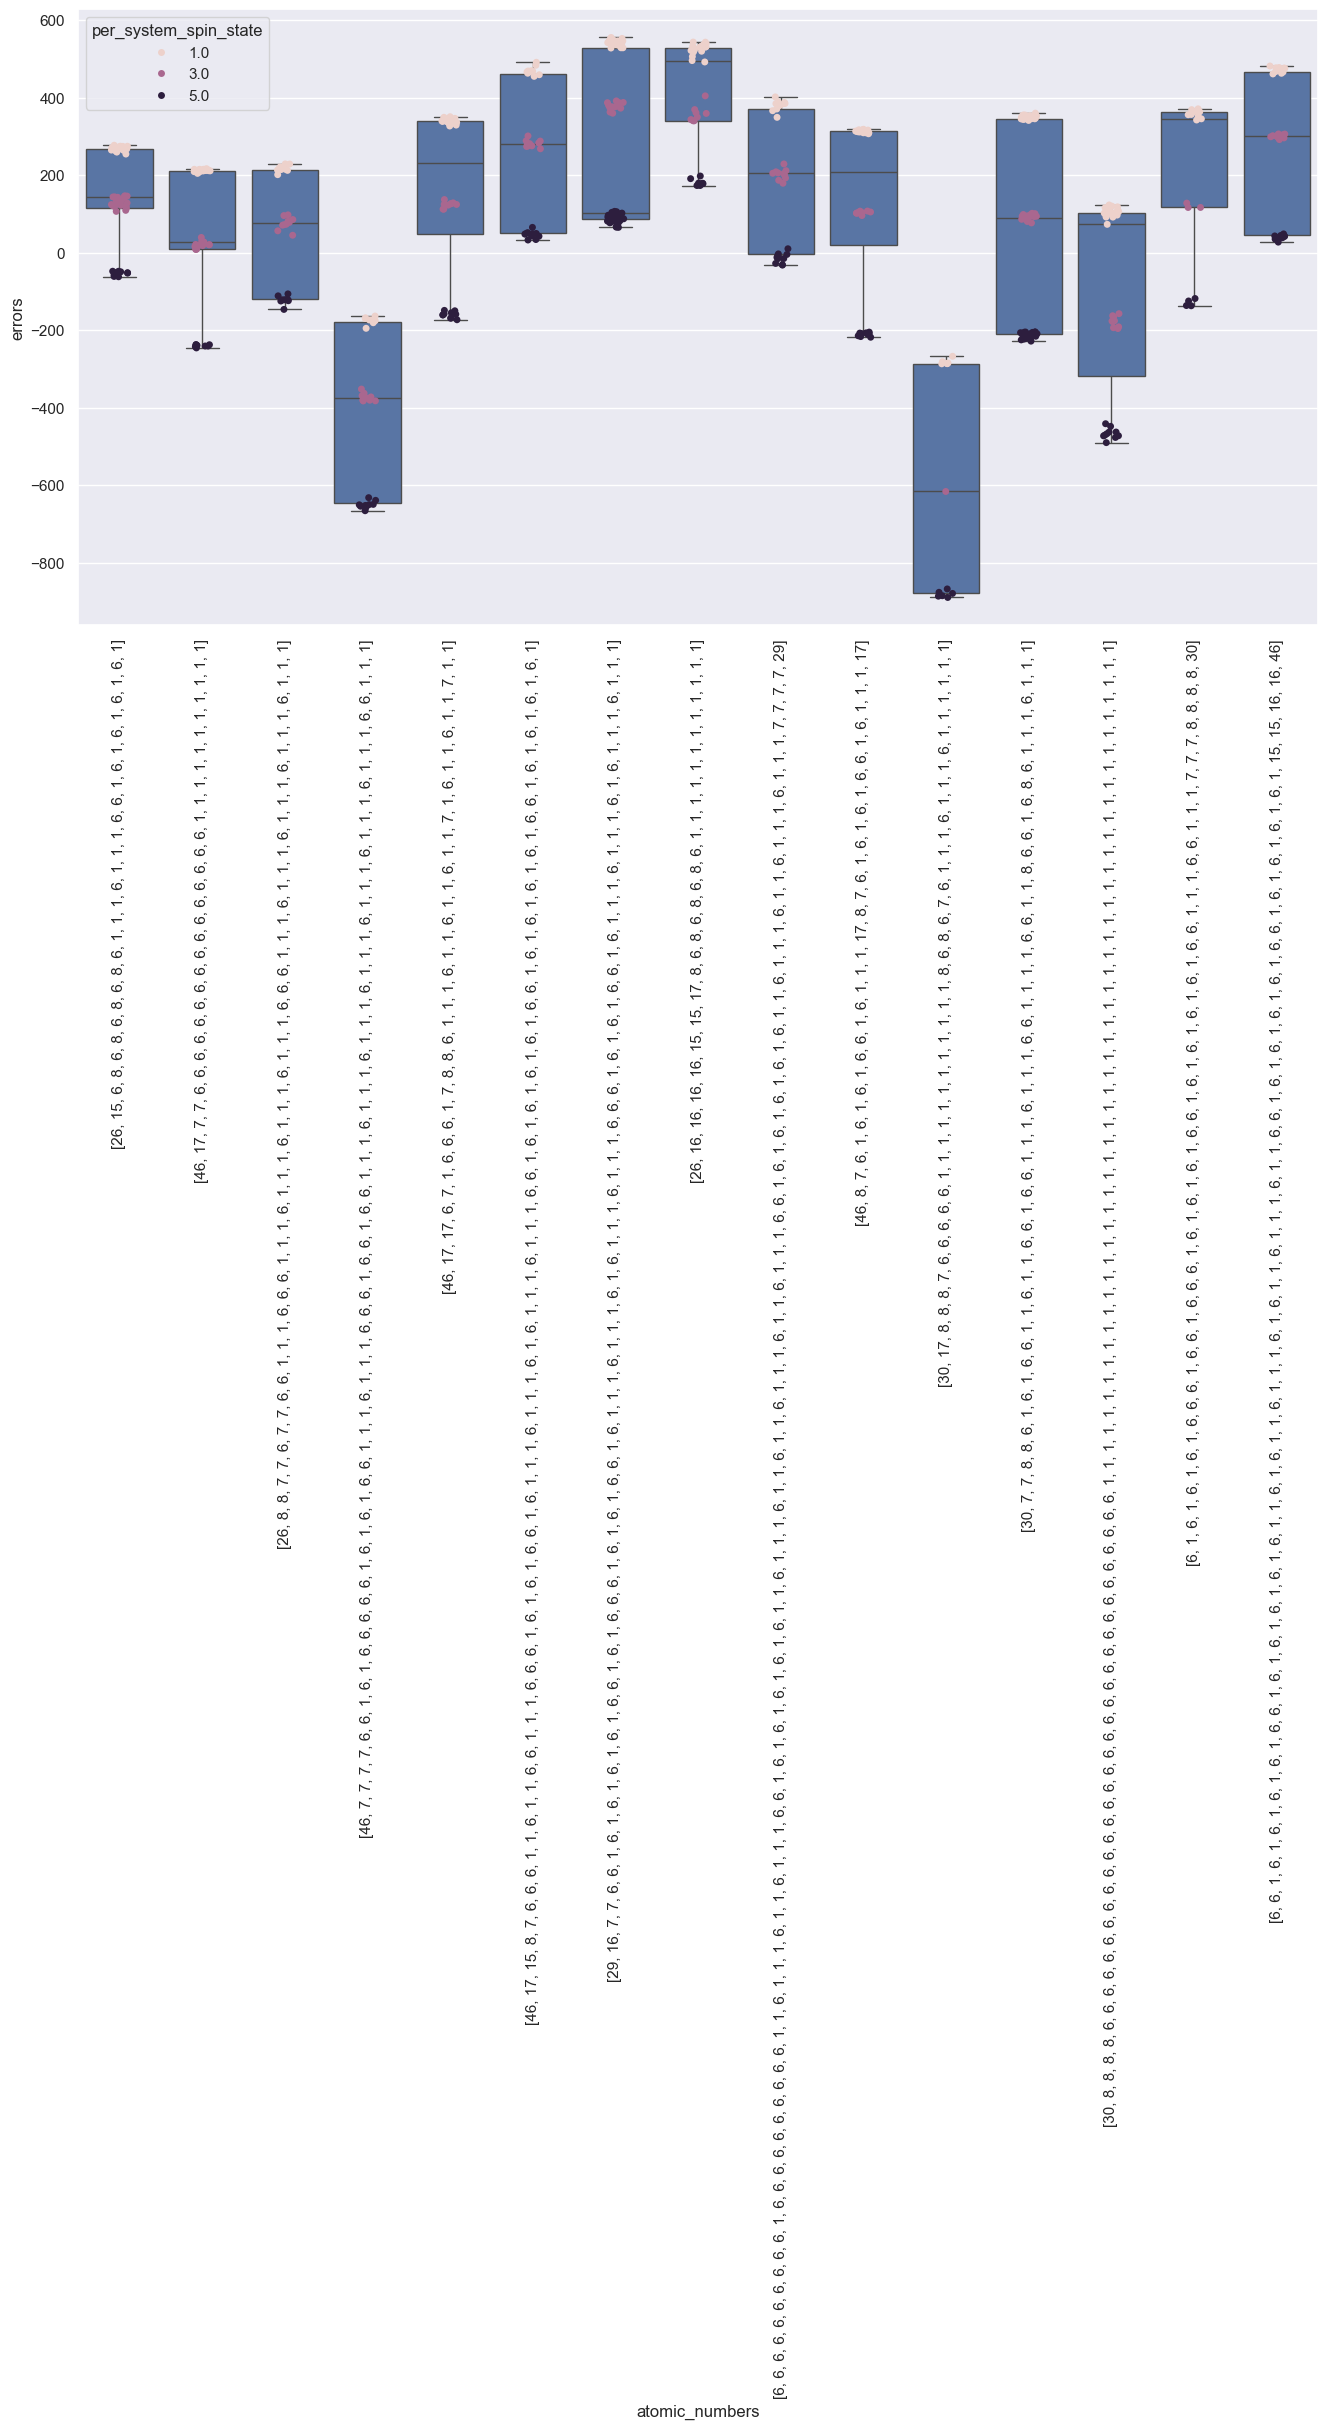

In [94]:
plt.figure(figsize=(16, 8))

sns.boxplot(data=df[:n_rows], x="atomic_numbers", y="errors",)
sns.stripplot(data=df[:n_rows], x="atomic_numbers", y="errors", hue="per_system_spin_state")

plt.xticks(rotation='vertical')
plt.show()

In [121]:
dm.torch_dataset[0]

BatchData(nnp_input=<modelforge.utils.prop.NNPInput object at 0x4527953f0>, metadata=<modelforge.utils.prop.Metadata object at 0x452795380>)

In [124]:
with torch.no_grad():  # Disable gradient tracking to save memory
    for i, batch in enumerate(dm.torch_dataset):
        if batch.nnp_input.per_system_total_charge.item() != 0:
            print(i)
            break